# Land cover from space, on your own Mac

One Sentinel-2 satellite scene over New York — **120 million pixels** — clustered into land-cover classes with
k-means. No labels, no training set, no cloud account. The same k-means you would run on a customer table, at a
size where the laptop is doing real work.

What makes this a fair demo rather than a toy: every pixel is used in every iteration, and the classes are
*discovered*, not looked up. Nothing in the run knows what a city or a river is.

**You need** an Apple Silicon Mac (M1 or later), Python 3.9+, and about 5 GB of disk for the download.
Memory is the thing to watch — see `DOWNSAMPLE` below. Run this on a **Python 3 kernel**.

In [ ]:
# If you cloned this repo, mlx_kmeans is already importable and this cell does nothing.
# Installing over a local checkout would shadow your working copy with the published one.
import importlib.util

if importlib.util.find_spec('mlx_kmeans') is None:
    %pip install 'mlx-kmeans @ git+https://github.com/kakollu/mlx-kmeans.git'
else:
    print('mlx_kmeans already available - skipping install')

%pip install -q rasterio matplotlib pandas scikit-learn


## 1. Get the scene

Four 10-metre bands — blue, green, red and near-infrared — from the public AWS `sentinel-cogs` bucket.
About 700 MB, and **no account or API key is needed**. Scene `S2A_18TWL_20240903_0_L2A` is a cloud-free
New York tile from 3 September 2024. Re-running this is free: it skips files it already has.

In [2]:
import subprocess, sys, time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'examples' else Path.cwd()
_ = subprocess.run([sys.executable, str(ROOT / 'scripts/get_data.py'), 'sentinel'], check=True)


sentinel: Sentinel-2 L2A scene over New York, bands B02/B03/B04/B08 (~700 MB)
   have data/sentinel/B02.tif (172 MB)
   have data/sentinel/B03.tif (179 MB)
   have data/sentinel/B04.tif (175 MB)
   have data/sentinel/B08.tif (191 MB)

done. Verify the benchmark numbers with:  .venv/bin/python bench.py --suite


## 2. Build the features

Six numbers per pixel: the four reflectance bands, plus two standard indices that make the classes
readable afterwards.

| Feature | Meaning |
|---|---|
| blue, green, red, nir | surface reflectance |
| **NDVI** = (nir − red) / (nir + red) | high for vegetation — leaves reflect infrared, absorb red |
| **NDWI** = (green − nir) / (green + nir) | high for water — water absorbs infrared |

The two indices are weighted ×2 so they are not drowned out by four raw bands. That is a judgement call, and
it is exactly the kind of choice worth changing to see whether your classes survive it.

**`DOWNSAMPLE` is the memory knob.** `1` reads the full 120M-pixel scene and needs roughly 8 GB free — fine on
a 32 GB+ Mac. On a MacBook Air start with `3` (13M pixels, under 1 GB); the map still looks right and everything
below still runs. Raise it once you have seen it work.

In [3]:
import numpy as np, rasterio

DOWNSAMPLE = 1          # 1 = full scene (~8 GB). Try 3 on a MacBook Air, then lower it.

DATA = ROOT / 'data' / 'sentinel'
BANDS = {'blue': 'B02.tif', 'green': 'B03.tif', 'red': 'B04.tif', 'nir': 'B08.tif'}

t = time.perf_counter()
arrays = {}
for name, fn in BANDS.items():
    with rasterio.open(DATA / fn) as src:
        h, w = src.height // DOWNSAMPLE, src.width // DOWNSAMPLE
        arrays[name] = src.read(1, out_shape=(h, w)).astype(np.float32)   # decimate while reading
shape = arrays['blue'].shape

stack = np.stack([arrays[b].ravel() for b in BANDS], axis=1)
valid = (stack > 0).all(1)                       # the scene is a rotated swath; corners are no-data
blue, green, red, nir = (stack[:, i] for i in range(4))
ndvi = ((nir - red) / (nir + red + 1e-6)).astype(np.float32)
ndwi = ((green - nir) / (green + nir + 1e-6)).astype(np.float32)
X = np.ascontiguousarray(np.column_stack([stack / 10000.0, ndvi * 2, ndwi * 2]).astype(np.float32)[valid])
read_s = time.perf_counter() - t

print(f'scene       {shape[0]} x {shape[1]} = {stack.shape[0]:,} pixels')
print(f'no-data     {stack.shape[0]-valid.sum():,} dropped ({(1-valid.mean())*100:.1f}%, outside the swath)')
print(f'to cluster  {len(X):,} pixels x {X.shape[1]} features = {X.nbytes/1e9:.2f} GB')
print(f'read+prep   {read_s:.1f}s')

scene       10980 x 10980 = 120,560,400 pixels
no-data     24,568,184 dropped (20.4%, outside the swath)
to cluster  95,992,216 pixels x 6 features = 2.30 GB
read+prep   6.4s


## 3. Cluster

This is the whole thing. `k=8` is a choice, not a discovery — try 5 and 12 later and see which story holds up.

In [4]:
from mlx_kmeans import KMeans

t = time.perf_counter()
model = KMeans(n_clusters=8, random_state=0).fit(X)
fit_s = time.perf_counter() - t
labels = model.labels_

print(f'{len(X):,} pixels -> 8 classes in {fit_s:.2f}s')
print(f'{model.n_iter_} iterations, {fit_s/model.n_iter_*1e3:.0f} ms each')
print(f'{len(X)*8*model.n_iter_/fit_s/1e9:.0f} billion pixel-to-center distances per second')
print(f'reading the files took {read_s/fit_s:.1f}x longer than clustering them')

95,992,216 pixels -> 8 classes in 0.95s
16 iterations, 60 ms each
13 billion pixel-to-center distances per second
reading the files took 6.7x longer than clustering them


## 4. Name the classes

k-means returns numbered groups. Numbers are not an answer — you have to look at what is in each one before
you believe it. Here each class is named from its own average NDVI and NDWI, *after* the fact.

This is the step people skip. In the taxi version of this demo, two of eight "behavioural" segments turned out
to differ only by payment method: the meter records a tip only when the fare is paid by card.

In [5]:
import pandas as pd

counts = np.bincount(labels, minlength=8)
C = model.cluster_centers_

def name(ndvi, ndwi):
    if ndwi > 0.15:  return 'water'
    if ndvi > 0.55:  return 'dense vegetation'
    if ndvi > 0.30:  return 'vegetation'
    if ndvi > 0.15:  return 'bare / low vegetation'
    return 'built-up / paved'

px_km2 = (10 * DOWNSAMPLE) ** 2 / 1e6          # each pixel covers this much ground
profile = pd.DataFrame([{
    'class': i, 'share': counts[i] / len(labels), 'km2': counts[i] * px_km2,
    'NDVI': C[i][4] / 2, 'NDWI': C[i][5] / 2, 'reads as': name(C[i][4] / 2, C[i][5] / 2),
} for i in range(8)]).sort_values('share', ascending=False).reset_index(drop=True)

profile.style.format({'share': '{:.1%}', 'km2': '{:,.0f}', 'NDVI': '{:+.2f}', 'NDWI': '{:+.2f}'})

,class,share,km2,NDVI,NDWI,reads as
0,5,38.9%,"3,737",+0.87,-0.77,dense vegetation
1,0,23.3%,"2,235",+0.79,-0.70,dense vegetation
2,6,10.5%,"1,007",+0.65,-0.60,dense vegetation
3,3,7.5%,717,+0.47,-0.46,vegetation
4,1,6.9%,658,+0.08,-0.11,built-up / paved
5,4,5.8%,560,+0.28,-0.29,bare / low vegetation
6,2,5.1%,493,-0.33,+0.52,water
7,7,2.0%,192,-0.12,+0.32,water


## 5. The map

Colours are the conventional land-cover ones, and each kind darkens with the index that defines it.

Worth knowing why: colouring each class by its own *average* reflectance — the obvious approach — washes the
map out to pastel, because averaging thousands of real pixels lands near mid-grey whatever the cover type is.

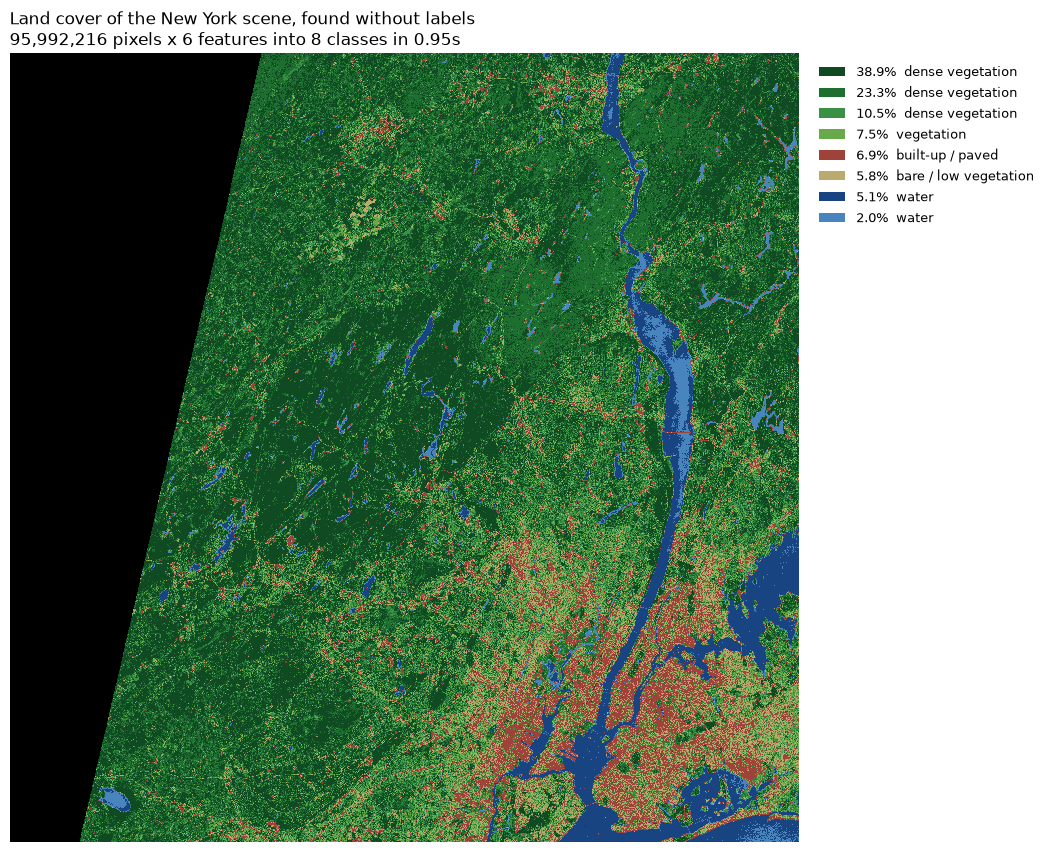

In [9]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

RAMPS = {'water': ['#184482', '#4884be', '#8cbae0'],
         'dense vegetation': ['#104a22', '#1e6e30', '#3a9146'],
         'vegetation': ['#68aa4a', '#8cc060'],
         'bare / low vegetation': ['#baaa6e', '#d6c894'],
         'built-up / paved': ['#9e423a', '#c47668']}

colour = {}
for kind, ramp in RAMPS.items():
    members = profile[profile['reads as'] == kind]
    members = members.sort_values('NDWI' if kind == 'water' else 'NDVI', ascending=False)
    for rank, cid in enumerate(members['class']):
        colour[cid] = ramp[min(rank, len(ramp) - 1)]

img = np.full(valid.shape, 8, dtype=np.uint8)
img[valid] = labels.astype(np.uint8)
step = max(1, 4 // DOWNSAMPLE)
img = img.reshape(shape)[::step, ::step]

fig, ax = plt.subplots(figsize=(11, 11), dpi=96)
ax.imshow(img, cmap=ListedColormap([colour[i] for i in range(8)] + ['#000000']), vmin=0, vmax=8,
          interpolation='nearest')
ax.set_title(f'Land cover of the New York scene, found without labels\n'
             f'{len(X):,} pixels x 6 features into 8 classes in {fit_s:.2f}s', fontsize=13, loc='left')
ax.axis('off')
ax.legend(handles=[Patch(facecolor=colour[r['class']], label=f"{r['share']:.1%}  {r['reads as']}")
                   for _, r in profile.iterrows()],
          loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False, fontsize=10)
plt.tight_layout(); plt.show()

Manhattan and the outer boroughs separate cleanly from the Hudson Valley forest; the Hudson, Long Island Sound
and Jamaica Bay come out as water; and the tan patches in the upper left are Orange County's "black dirt" farm
belt. None of that was told to the algorithm — it is six numbers per pixel and a distance.

The black wedge is not a bug: the satellite's swath is rotated relative to the tile, so those pixels have no data.

## 6. Is it actually fast?

Same 10M pixels, same 8 clusters, same machine — against scikit-learn, the standard CPU implementation.
Both are doing exact Lloyd k-means on all the rows they are given.

In [10]:
from sklearn.cluster import KMeans as SKMeans

sub = X[:10_000_000]

t = time.perf_counter(); SKMeans(n_clusters=8, n_init=1, max_iter=model.n_iter_, random_state=0).fit(sub)
sk_s = time.perf_counter() - t
t = time.perf_counter(); KMeans(n_clusters=8, max_iter=model.n_iter_, tol=0.0, random_state=0).fit(sub)
ours_s = time.perf_counter() - t

print(f'scikit-learn  {sk_s:6.2f}s')
print(f'mlx-kmeans    {ours_s:6.2f}s   ({sk_s/ours_s:.0f}x faster on this machine)')

scikit-learn    2.14s
mlx-kmeans      0.11s   (19x faster on this machine)


## What to take from this

- **Scale is not the obstacle it used to be.** 96M rows in about a second on a laptop means you can cluster the
  whole population instead of a sample, and re-run it while you are still thinking.
- **Reading the data is now the slow part.** Once the fit is faster than the file read, making the algorithm
  faster stops helping — which is a good problem to have, and a sign to go measure the pipeline instead.
- **The discipline did not change.** Standardise or weight your features deliberately, profile every cluster
  before naming it, and vary `k` before you believe any particular story.

**Honest limits.** These are unsupervised groupings, not a validated land-cover product — a real one is checked
against ground truth. Timings here are from one Apple M5 Max; your Mac will differ, and below roughly 100k rows
scikit-learn is often the faster choice. Vary `k` and re-run: if a class disappears at `k=7`, it was never solid.

Source and benchmarks: **github.com/kakollu/mlx-kmeans**